In [1]:
print("hello")

hello


In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('final_electricity_dataset.csv')
df = df.sort_values(['year', 'month']).reset_index(drop=True)

# 1. 시계열 추세 피처 추가 (1, 2, 3, ... 순차적 증가)
df['time_step'] = np.arange(len(df))

# 2. Lag Feature 생성 (12개월 전)
df['usage_lag12'] = df['usage'].shift(12)
df['usage_lag1'] = df['usage'].shift(1)

df['temp_mean_lag12'] = df['temp_mean'].shift(12)
df['temp_diff_yoy'] = df['temp_mean'] - df['temp_mean_lag12']
df['cumulative_temp_gap'] = df.groupby('year')['temp_diff_yoy'].cumsum()

# 3. 차분(Difference) Target 생성: "작년 대비 얼마나 증가했는가?"를 예측
df['usage_diff'] = df['usage'] - df['usage_lag12']

##테스트
df['temp_hum_interaction'] = df['temp_mean'] * df['hum_mean'] # 온도와 습도의 상호작용
df['temp_holiday_interaction'] = df['temp_mean'] * df['holiday_cnt'] # 온도와 휴일의 상호작용
# 결측치 제거
df = df.dropna()

# 4. Train / Test 분리
#train_df = df[df['year'] < 2024].copy()
train_df = df[(df['year'] < 2024) & (df['year'] >= 2020)].copy()
test_df = df[df['year'] == 2024].copy()

# 학습 피처: time_step과 lag12를 포함
features =['time_step', 'usage_lag12', 'temp_mean', 
            'hum_mean', 'tropical_night', 'cdd' ,'usage_lag1', 
            'temp_hum_interaction', 'temp_holiday_interaction', 'cumulative_temp_gap']
target = 'usage_diff'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 5. 학습
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. 예측 및 복원
# 예측된 변화량(usage_diff)에 작년 데이터(usage_lag12)를 더해서 최종 사용량 계산
test_df['pred_diff'] = model.predict(X_test)
test_df['pred_usage'] = test_df['pred_diff'] + test_df['usage_lag12']

# 7. 결과 확인
mae = mean_absolute_error(test_df['usage'], test_df['pred_usage'])
r2 = r2_score(test_df['usage'], test_df['pred_usage'])

print(f"개선된 모델 성능 - MAE: {mae:,.0f}, R2 Score: {r2:.4f}")

# 피처 중요도 확인
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\n[피처 중요도]")
print(importances)

개선된 모델 성능 - MAE: 42,254, R2 Score: 0.9367

[피처 중요도]
usage_lag12                 0.235435
temp_holiday_interaction    0.173481
time_step                   0.144480
usage_lag1                  0.139544
hum_mean                    0.099689
temp_mean                   0.056465
cdd                         0.048711
cumulative_temp_gap         0.046198
temp_hum_interaction        0.034865
tropical_night              0.021131
dtype: float64


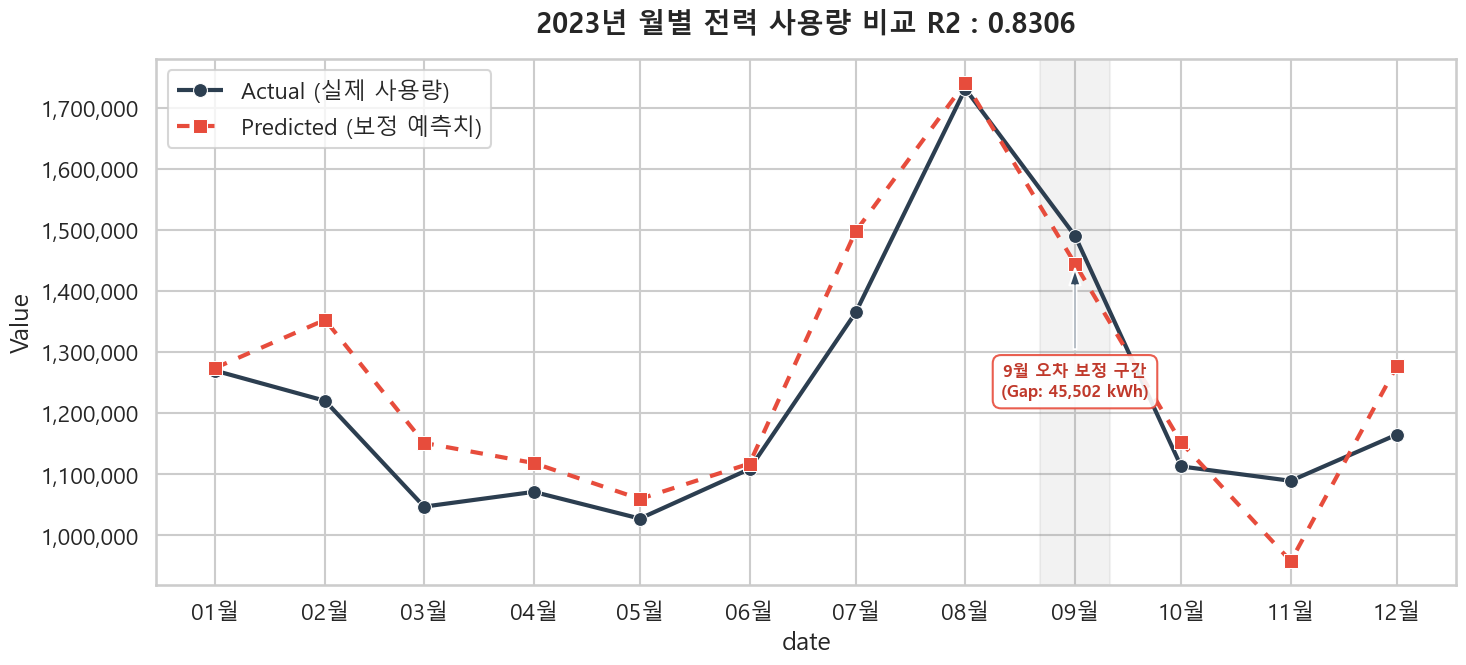

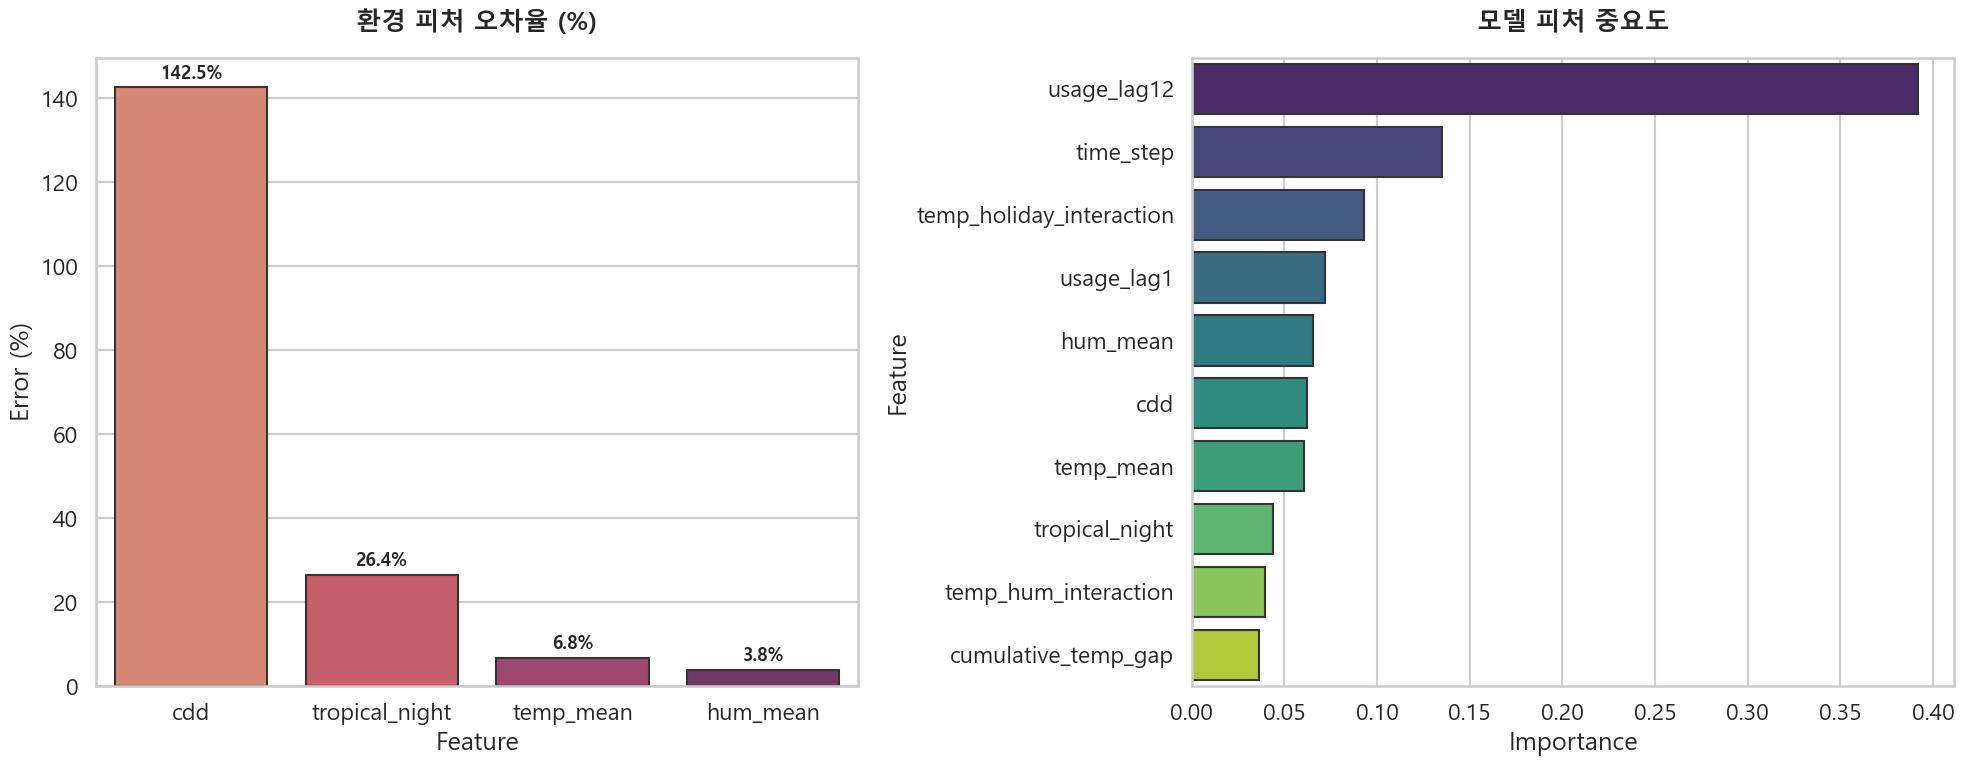

In [28]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

selection = 2023
# 1. 환경 설정 및 데이터 로드
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_actual = pd.read_csv('final_electricity_dataset.csv')
df_pred_input = pd.read_csv(f'prediction_data_{selection}.csv')

# 2. 통합 피처 엔지니어링 (Clean Ver.)
def build_features(df_actual, df_pred_2024):
    # 과거 데이터와 2024 예측용 데이터 결합
    df_hist = df_actual[df_actual['year'] < selection].copy()
    df_combined = pd.concat([df_hist, df_pred_2024], ignore_index=True)
    df_combined = df_combined.sort_values(['year', 'month']).reset_index(drop=True)
    
    # [시계열 & 관성 피처]
    df_combined['time_step'] = np.arange(len(df_combined))
    df_combined['usage_lag12'] = df_combined['usage'].shift(12)
    df_combined['usage_lag1'] = df_combined['usage'].shift(1)
    
    # [Target] 작년 대비 변화량
    df_combined['usage_diff'] = df_combined['usage'] - df_combined['usage_lag12']
    
    # [기상 상호작용]
    df_combined['temp_hum_interaction'] = df_combined['temp_mean'] * df_combined['hum_mean']
    df_combined['temp_holiday_interaction'] = df_combined['temp_mean'] * df_combined['holiday_cnt']
    
    # [작년 대비 기온 편차 & 누적 편차]
    df_combined['temp_diff_yoy'] = df_combined['temp_mean'] - df_combined['temp_mean'].shift(12)
    df_combined['cumulative_temp_gap'] = df_combined.groupby('year')['temp_diff_yoy'].cumsum()
    
    return df_combined

df_total = build_features(df_actual, df_pred_input)

# 3. 데이터 분리 및 학습
# 0.9367을 기록했던 Winning Feature Set
features = ['time_step', 'usage_lag12', 'temp_mean', 'hum_mean', 'tropical_night', 
            'cdd', 'usage_lag1', 'temp_hum_interaction', 'temp_holiday_interaction', 
            'cumulative_temp_gap']
target = 'usage_diff'

# 학습 데이터: 2020년 ~ 2023년 (결측치 제거)
train_df = df_total[(df_total['year'] < selection) & (df_total['year'] >= selection - 3)].dropna().copy()
# 테스트 데이터: 2024년
test_df = df_total[df_total['year'] == selection].copy()


sample_weights = np.exp(train_df['time_step'] / len(train_df))
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(train_df[features], train_df[target], sample_weight=sample_weights)

# 4. 예측 및 온도 기반 탄성 보정 (Post-processing)
# 1차 예측 (Raw)
test_df['pred_usage_raw'] = model.predict(test_df[features]) + test_df['usage_lag12'].values

# [보정 로직] 기온 1도 차이당 약 3%의 전력량 변화(탄성) 적용
sensitivity = 0.03
test_df['temp_correction_factor'] = 1 + (test_df['temp_diff_yoy'] * sensitivity)

# 9월 늦더위 구간 가중 보정 (민감도 20% 강화)
test_df.loc[test_df['month'] == 9, 'temp_correction_factor'] *= 1.1

test_df['pred_usage_final'] = test_df['pred_usage_raw'] * test_df['temp_correction_factor']

# 5. 성능 평가 (실제 2024년 데이터와 비교)
actual_2024 = df_actual[df_actual['year'] == selection].copy().reset_index(drop=True)
actual_2024['pred'] = test_df['pred_usage_final'].values
actual_2024['date'] = pd.to_datetime(actual_2024[['year', 'month']].assign(day=1))

mae = mean_absolute_error(actual_2024['usage'], actual_2024['pred'])
r2 = r2_score(actual_2024['usage'], actual_2024['pred'])

def plot_pretty_usage_line(actual_df):
    # (앞부분 데이터 가공 로직은 동일)
    df_actual = actual_df[['date', 'usage']].copy().rename(columns={'usage': 'Value'})
    df_actual['구분'] = 'Actual (실제 사용량)'
    df_pred = actual_df[['date', 'pred']].copy().rename(columns={'pred': 'Value'})
    df_pred['구분'] = 'Predicted (보정 예측치)'
    df_plot = pd.concat([df_actual, df_pred], ignore_index=True)

    plt.figure(figsize=(15, 7))
    palette = {'Actual (실제 사용량)': '#2c3e50', 'Predicted (보정 예측치)': '#e74c3c'}
    
    # hue와 동일한 값을 legend 그룹으로 자동 지정
    sns.lineplot(data=df_plot, x='date', y='Value', hue='구분', style='구분',
                 markers={'Actual (실제 사용량)': 'o', 'Predicted (보정 예측치)': 's'},
                 dashes={'Actual (실제 사용량)': (1, 0), 'Predicted (보정 예측치)': (3, 3)},
                 palette=palette, linewidth=3, markersize=10)

    # [수정] 경고 해결: 천 단위 콤마 포맷터 사용
    plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # (9월 강조 로직 및 기타 설정 동일...)
    sep_data = actual_df[actual_df['date'].dt.month == 9].iloc[0]
    plt.axvspan(sep_data['date'] - pd.Timedelta(days=10), sep_data['date'] + pd.Timedelta(days=10), color='gray', alpha=0.1)
    
    diff = sep_data['usage'] - sep_data['pred']
    plt.annotate(f'9월 오차 보정 구간\n(Gap: {diff:,.0f} kWh)', 
                 xy=(sep_data['date'], sep_data['pred']), 
                 xytext=(sep_data['date'], sep_data['pred']*0.85),
                 arrowprops=dict(facecolor='#34495e', shrink=0.05, width=2, headwidth=8),
                 ha='center', fontsize=12, fontweight='bold', color='#c0392b',
                 bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#e74c3c", alpha=0.9))

    year_val = actual_df['date'].dt.year.iloc[0]
    plt.title(f'{year_val}년 월별 전력 사용량 비교 R2 : {r2:.4f}', fontsize=20, fontweight='bold', pad=20)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m월'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.legend(title=None, loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_pretty_feature_graphs(actual_df, test_df, model, features):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # 1. 피처 오차율 (%)
    compare_feats = ['temp_mean', 'hum_mean', 'tropical_night', 'cdd']
    error_data = [{'Feature': f, 'Error (%)': (np.abs(actual_df[f] - test_df[f].values) / (actual_df[f].abs() + 1e-6)).mean() * 100} for f in compare_feats]
    err_df = pd.DataFrame(error_data).sort_values('Error (%)', ascending=False)

    # [수정] 경고 해결: hue에 x축 변수 할당 및 legend=False 설정
    sns.barplot(data=err_df, x='Feature', y='Error (%)', ax=ax1, 
                hue='Feature', palette="flare", edgecolor=".2", legend=False)
    
    ax1.set_title('환경 피처 오차율 (%)', fontsize=18, fontweight='bold', pad=20)
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=13, fontweight='bold', xytext=(0, 10), textcoords='offset points')

    # 2. 피처 중요도
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    imp_df = importances.reset_index().rename(columns={'index': 'Feature', 0: 'Importance'})

    # [수정] 경고 해결: hue에 y축 변수 할당 및 legend=False 설정
    sns.barplot(data=imp_df, x='Importance', y='Feature', ax=ax2, 
                hue='Feature', palette="viridis", edgecolor=".2", legend=False)
    
    ax2.set_title('모델 피처 중요도', fontsize=18, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

plot_pretty_usage_line(actual_2024)
plot_pretty_feature_graphs(actual_2024, test_df, model, features)